In [2]:
from pathlib import Path
import sys
project_root = Path.cwd().parents[1]
sys.path.insert(0,  str(project_root / 'src'))
from data_processing import Data
from fit_analysis import FitResult

from detector_region import DetectorRegion

import numpy as np
import matplotlib.pyplot as plt

In [72]:
path16 = Path.cwd() / 'data' / 'test_11' 
path96 = Path.cwd() / 'data' / '96ns_outer_coincidence_11'
path23  = Path.cwd() / 'data' / 'test_23' 

data16, data96, data23 = [], [], []
for ch_data, pdir in [[data16,path16],[data96,path96],[data23,path23]]:
   for ch in range(4):
      token = f'DataR_CH{ch}@DT5751_1616'
      pdir_raw = pdir / 'RAW'
      matching_files = [f for f in pdir_raw.iterdir() if f.is_file() and token in f.name]
      if len(matching_files) == 1:
         _s = [index for index, char in enumerate(pdir.name) if char == '_']
         id = pdir.name[_s[0]+1:] if len(_s)==1 else pdir.name[_s[0]+1:_s[1]]
         ch_data.append(Data(id=id))
         try:
            ch_data[-1].load_file(matching_files[0], lowmem=False)
         except FileExistsError as e:
            print(ch, pdir)
            raise e
      else:
         print(f'No file found with token: DataR_CH{ch}@DT5751_1616')

print('-- 16 ns: --')
for ch in data16: print(ch)
print('\n-- 96 ns: --')
for ch in data96: print(ch)

data_dict = {'16': data16, '96': data96}

-- 16 ns: --
            0 |                 2017 |      59643 s |   0.03 ± 0.00 (events/s) |                   38 
            1 |                 1929 |      59643 s |   0.03 ± 0.00 (events/s) |                    4 
            2 |                 1929 |      59643 s |   0.03 ± 0.00 (events/s) |                   13 
            3 |                 2017 |      59643 s |   0.03 ± 0.00 (events/s) |                  464 

-- 96 ns: --
            0 |                  830 |      17499 s |   0.05 ± 0.00 (events/s) |                   19 
            1 |                  790 |      17499 s |   0.05 ± 0.00 (events/s) |                    3 
            2 |                  788 |      17499 s |   0.05 ± 0.00 (events/s) |                    6 
            3 |                  830 |      17499 s |   0.05 ± 0.00 (events/s) |                    6 


In [4]:
# Filter out noise by eliminating events that don't have triple coincidence

def filter_noise(coincidence_level, acceptance_time=1.6e-8, plots = False):

   new_tests = []
   master_nmt = []
   for id, test in data_dict.items():
      print(f'--- {id} ns: ---\n')
      masks = [[] for ch in test]
      masks_1 = [[] for ch in test]
      masks_2 = [[] for ch in test]
      idxs = [0 for ch in test]
      ch_times = [ch.db['Time'] for ch in test]
      dts, noise_counts = [],[0 for ch in test]
      no_missed_times,negative_dts,l_negative_dts = [],[],[]
      for t in ch_times[0]: # Channels 0 and 3 are the coincidence channels => always have all events
         noise = True
         # Check for coincidence in chs 1 and 2
         if int(id)<7 or int(id)>=60: ti,tf = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the top scintillator while channel 0 is at the bottom for tests 0-6
         elif int(id)>=7: tf,ti = ch_times[3][idxs[3]],ch_times[0][idxs[0]] # Channel 3 is the bottom scintillator while channel 0 is at the top for tests 7-28
         dt = tf - ti
         # if dt>0: print(dt)
         dts.append(dt)

         t0 = ch_times[0][idxs[0]],
         print((ch_times[0][idxs[0]]-t0)*1e9,(ch_times[1][idxs[1]]-t0)*1e9,(ch_times[2][idxs[2]]-t0)*1e9,(ch_times[3][idxs[3]]-t0)*1e9)
         if (np.abs(ch_times[0][idxs[1]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 > 16) and (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 < 96): 
            print("!!")
         #    print(test[3].db['Energy'][idxs[3]])
         if (np.abs(ch_times[0][idxs[2]]- ch_times[3][idxs[3]])*1e9 < 16) and (np.abs(ch_times[2][idxs[2]]- ch_times[3][idxs[3]])*1e9 > 16) and (np.abs(ch_times[1][idxs[1]]- ch_times[3][idxs[3]])*1e9 < 96): 
            print("!!")
         #    print(test[3].db['Energy'][idxs[3]])


         # t_c = ch_times[3][idxs[3]]+dts[idxs[3]]/2
         # if id=='3':
         #    print(len(ch_times[3])-1-idxs[3],len(ch_times[1])-1-idxs[1])
         # try:
         #    ch_times[1][idxs[1]]
         # except:
         #    print(f"{ch_times[3][-1]} versus {ch_times[2][-1]}")
         #    print(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} and Channel 2 is on {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # if id == '3':
            # print(np.abs(t_c - ch_times[1][idxs[1]]))
         # blud = False
         # if np.abs(t_c - ch_times[1][idxs[1]]) > acceptance_time:
         #    # print("!^!", noise_counts[3] - noise_counts[1], idxs[3] - idxs[1])
         #    blud = True
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 or np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    # print("!!^!!")
         #    print(np.abs(t_c - ch_times[1][idxs[1]]))
         #    print(tf-ti,tf-ch_times[1][idxs[1]])
         # if (np.abs(ti - ch_times[1][idxs[1]]) > 1.6e-8 and np.abs(tf - ch_times[1][idxs[1]]) > 1.6e-8) and not blud:
         #    print('Aha!')

         # Determine if either of channels 1 and 2 were triggered
         acceptable = [ti - acceptance_time, tf + acceptance_time]
         try:
            ch_1_event = True if (ch_times[1][idxs[1]]>acceptable[0] and ch_times[1][idxs[1]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_1_event = False
            else:
               raise IndexError(f"Channel 1 is on index {idxs[1]}/{len(ch_times[1])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")
         try:
            ch_2_event = True if (ch_times[2][idxs[2]]>acceptable[0] and ch_times[2][idxs[2]]<acceptable[1]) else False
         except:
            if len(ch_times[3])-1==idxs[3]:
               ch_2_event = False
            else:
               raise IndexError(f"Channel 2 is on index {idxs[2]}/{len(ch_times[2])-1} while Channel 0 is on {idxs[0]}/{len(ch_times[0])-1}")

         # Determine whether the event is noise based on coincidence level
         if 2 + ch_1_event + ch_2_event >= coincidence_level: noise = False

         # Update masks to account for noise
         if not noise:
            masks[0].append(True)
            if ch_1_event: masks[1].append(True)
            if ch_2_event: masks[2].append(True)
            masks[3].append(True)
            masks_1[0].append(False)
            if ch_1_event: masks_1[1].append(False)
            if ch_2_event: masks_1[2].append(False)
            masks_1[3].append(False)
            masks_2[0].append(False)
            if ch_1_event: masks_2[1].append(False)
            if ch_2_event: masks_2[2].append(False)
            masks_2[3].append(False)
         else:
            masks[0].append(False)
            if ch_1_event: masks[1].append(False)
            if ch_2_event: masks[2].append(False)
            masks[3].append(False)
            noise_counts[0] += 1
            if ch_1_event: noise_counts[1] += 1
            if ch_2_event: noise_counts[2] += 1
            noise_counts[3] += 1

            if ch_1_event:
               masks_1[0].append(True)
               if ch_1_event: masks_1[1].append(True)
               if ch_2_event: masks_1[2].append(True)
               masks_1[3].append(True)
            else:
               masks_1[0].append(False)
               if ch_1_event: masks_1[1].append(False)
               if ch_2_event: masks_1[2].append(False)
               masks_1[3].append(False)
            if ch_2_event:
               masks_2[0].append(True)
               if ch_1_event: masks_2[1].append(True)
               if ch_2_event: masks_2[2].append(True)
               masks_2[3].append(True)
            else:
               masks_2[0].append(False)
               if ch_1_event: masks_2[1].append(False)
               if ch_2_event: masks_2[2].append(False)
               masks_2[3].append(False)

         # Update no_missed_times
         if ch_1_event and ch_2_event:
            no_missed_times.append(np.array([ch_times[ch][idxs[ch]] for ch in range(4)]))
         
         if dt<0:
            chs_seen = 2
            if ch_1_event: chs_seen+=1
            if ch_2_event: chs_seen+=1
            negative_dts.append(chs_seen)
            if dt<-5e-9:
               l_negative_dts.append(chs_seen)

         # Update indexing
         idxs[0] += 1
         if ch_1_event: idxs[1] += 1
         if ch_2_event: idxs[2] += 1
         idxs[3] += 1

         
      masks = [np.array(mask) for mask in masks]
      masks_1 = [np.array(mask) for mask in masks_1]

      if plots:
         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Small-Peak Channel 0 Events which Were Caught by Channel 3 but\nWere Missed in Channels 1 and 2")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time (s)")
               axs[i].set_ylabel("Signal (mV)")
               waves = test[ch].db['Signal'][~masks[0]]
               print(len(waves))
               small_peak_waves = [wave for wave in waves if np.max(wave)<20]
               print(len(small_peak_waves))
               for k in range(len(small_peak_waves)):
                  small_peak_wave = small_peak_waves[k]
                  ns = np.linspace(0,len(small_peak_wave),len(small_peak_wave))
                  axs[i].plot(ns, small_peak_wave,label=f"Wave {k}")
         # plt.legend()
         plt.tight_layout()
         plt.show()

         fig, axs = plt.subplots(1,2,figsize=(8,4))
         fig.suptitle("Histogram of the Time Difference Between Events in Channel 0 with a Small\nPeak that Were Missed in Channel 1 and 2 but not Channel 3")
         for i in range(2):
               ch = [0,3][i]
               axs[i].set_title(f"Channel {ch}")
               axs[i].set_xlabel("Time Difference (ns)")
               axs[i].set_ylabel("Counts")
               waves = test[ch].db['Signal'][~masks[0]]
               small_peak_dts = waves = [dts[i]*1e9 for i in range(len(waves)) if np.max(waves[i])<20]
               axs[i].hist(small_peak_dts)
         # plt.legend()
         plt.tight_layout()
         plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 1 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_1[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

         # fig, axs = plt.subplots(2,2,figsize=(8,8))
         # fig.suptitle("Channel 2 noise events")
         # for i in range(2):
         #    for j in range(2):
         #       ch = i*2+j
         #       axs[i][j].set_title(f"Channel {ch}")
         #       axs[i][j].set_xlabel("Time (s)")
         #       axs[i][j].set_ylabel("Signal (mV)")
         #       waves = test[ch].db['Signal'][masks_2[ch]]
         #       for k in range(len(waves)):
         #          wave = waves[k]
         #          ns = np.linspace(0,len(wave),len(wave))
         #          axs[i][j].plot(ns, wave,label=f"Wave {k}")
         # plt.legend()
         # plt.tight_layout()
         # plt.show()

      no_missed_times = np.transpose(np.array(no_missed_times))

      new_test = []
      for ch in range(len(test)):
         new_test.append(test[ch] % masks[ch]) # Apply mask to all data

      dts = np.array(dts)
      print(f"{id} - Non-positive travel times from channel 0 to channel 3: {len(dts[np.array(dts)<0])/len(dts)*100:.2f}% ({len(dts[np.array(dts)<0])} events)")
      for ch in range(4):
         print(f'\tChannel {ch} Number of events identified as noise: {noise_counts[ch]:>2} ({noise_counts[ch]/len(ch_times[ch])*100:.2f}%)')
      print(f'\t{len(new_test[0].db['Time'])} =? {len(new_test[1].db['Time'])} =? {len(new_test[2].db['Time'])} =? {len(new_test[3].db['Time'])}')
      print(f'\tnmt: {no_missed_times.shape}')
      print(f'\t{len(negative_dts)} events had a negative travel time between channel 0 and channel 3. {negative_dts.count(2)/len(negative_dts)*100:.2f}% seen by only outers, {negative_dts.count(3)/len(negative_dts)*100:.2f}% seen by exactly 3, {negative_dts.count(4)/len(negative_dts)*100:.2f}% seen by all 4')
      print(f'\t{len(l_negative_dts)} events had a travel time between channel 0 and channel 3 less than -5 ns. {l_negative_dts.count(2)/len(l_negative_dts)*100:.2f}% seen by only outers, {l_negative_dts.count(3)/len(l_negative_dts)*100:.2f}% seen by exactly 3, {l_negative_dts.count(4)/len(l_negative_dts)*100:.2f}% seen by all 4')
      print()

      new_tests.append(new_test)
      master_nmt.append(no_missed_times)
   
   return new_tests, master_nmt

In [5]:
new_tests,nmt = filter_noise(coincidence_level = 3,acceptance_time = 4.5e-7,plots=False)

i=0
for key in data_dict.keys():
   # print(key,data_dict[key][0].id, nmt[i].shape)
   # data_dict[key]= (data_dict[key],nmt[i])
   print(key,new_tests[i][0].id, nmt[i].shape)
   data_dict[key]= (new_tests[i],nmt[i])
   i+=1

# Create DetectorRegion objects
for key, test in data_dict.items():
   print(len(test))
   for ch in range(4):
      print(test[0][ch],'\n',len(test[1][ch]))
      print(test[1][ch][0:5])
   data_dict[key] = [DetectorRegion(key, test[0][ch],test[1][ch]) for ch in range(4)]

--- 16 ns: ---

[0.] [11.74900177] [7.74900144] [8.74900152]
[0.] [17.50100864] [1.35957625e+10] [11.50100104]
!!
[0.] [11.12499604] [7.62599939] [8.93798813]
[0.] [5.99999339] [9.25000165] [11.50100104]
[0.] [7.25097493] [8.00000066] [9.43799705]
[0.] [10.87499868] [10.62599608] [11.37499339]
[0.] [12.37597758] [8.62499405] [9.99997951]
[0.] [3.37502115] [4.50000925] [8.75002115]
[0.] [6.50004495] [6.25101393] [8.12502776]
[0.] [8.62496563] [7.87599674] [9.12496034]
[0.] [6.62498678] [6.37498943] [7.37497885]
[0.] [11.12596237] [7.24998017] [10.50000265]
[0.] [7.12498149] [8.12502776] [10.12500661]
[0.] [11.37499339] [10.12500661] [10.6260245]
[0.] [7.12498149] [5.87596105] [7.12498149]
[0.] [7.12498149] [6.62498678] [8.87598617]
[0.] [8.37599146] [7.62508989] [8.43704129]
[0.] [5.75096237] [5.75096237] [7.12498149]
[0.] [7.49901119] [8.24900326] [9.62404556]
[0.] [10.00000793] [7.24992333] [10.00000793]
[0.] [9.3749577] [4.75006345] [9.87597559]
[0.] [5.87499471] [7.12589099] [9.3749

In [6]:
def compare_timing(ref_i,d_dict,display=False):
   ref_t_dict = {}
   for key in d_dict.keys():
      print(d_dict[key])
      test = d_dict[key][ref_i]
      t = test.nmt
      ref_t_dict[key] = t

   mu_t_list,sigma_t_list = [],[]
   for ch in range(4):
      if display: print(f"Channel {ch}")
      mu_t_dict,sigma_t_dict = {},{}
      for key in d_dict.keys():
         if ch == ref_i:
            mu_t_dict[int(key)] = 0
            sigma_t_dict[int(key)] = 0
            if display: print(f"{key} - μ: {0.0} ns, σ: {0.0} ns")
         else:
            test = d_dict[key][ch]
            ref_t = ref_t_dict[key]
            plt.title(f"Comparing Channel {ref_i} to Channel {ch} ({key} ns)")
            mu, sigma = test.get_dt_params(ref_t,plot=False) if not display else test.get_dt_params(ref_t,plot=True)
            mu_t_dict[int(key)] = np.abs(mu)*1e9 # Convert to ns
            sigma_t_dict[int(key)] = sigma*1e9 # Convert to ns
            if display: print(f"{key} - μ: {mu*1e9:.6f} ns, σ: {sigma*1e9:.6f} ns")
      mu_t_list.append(mu_t_dict)
      sigma_t_list.append(sigma_t_dict)

   return mu_t_list, sigma_t_list

[<detector_region.DetectorRegion object at 0x116b8e7b0>, <detector_region.DetectorRegion object at 0x1127a79d0>, <detector_region.DetectorRegion object at 0x116b07390>, <detector_region.DetectorRegion object at 0x11729c2b0>]
[<detector_region.DetectorRegion object at 0x11729c510>, <detector_region.DetectorRegion object at 0x1175ac050>, <detector_region.DetectorRegion object at 0x117458490>, <detector_region.DetectorRegion object at 0x1174585a0>]
Channel 0
16 - μ: 0.0 ns, σ: 0.0 ns
96 - μ: 0.0 ns, σ: 0.0 ns
Channel 1


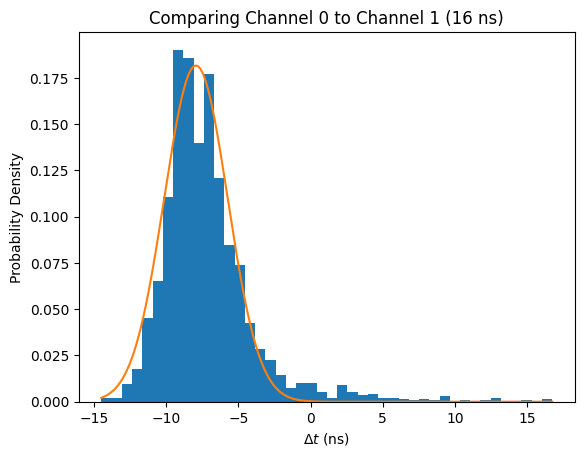

16 - μ: -7.944644 ns, σ: 2.195739 ns


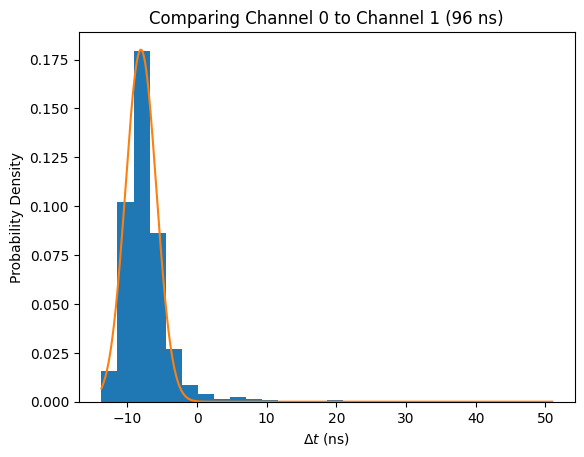

96 - μ: -8.069950 ns, σ: 2.215972 ns
Channel 2


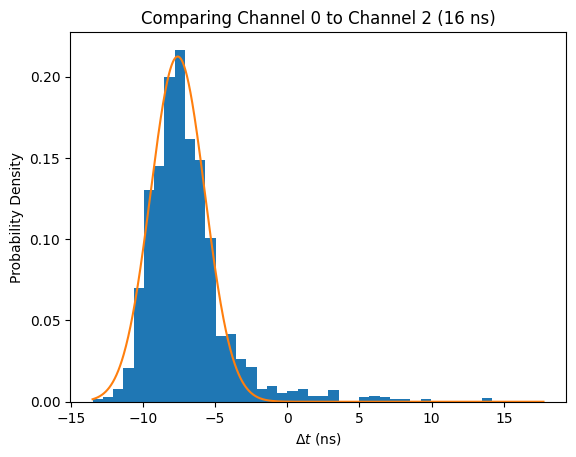

16 - μ: -7.598108 ns, σ: 1.878122 ns


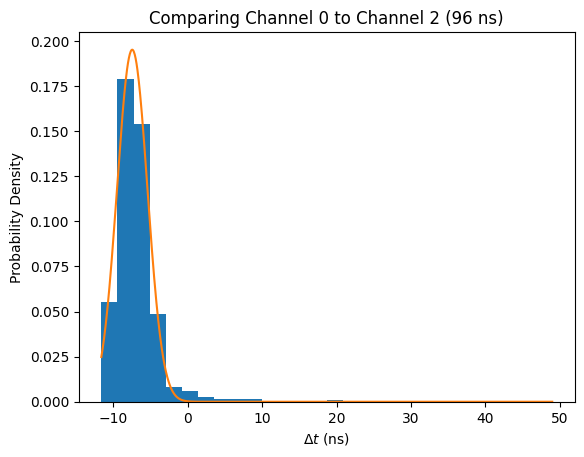

96 - μ: -7.470075 ns, σ: 2.044317 ns
Channel 3


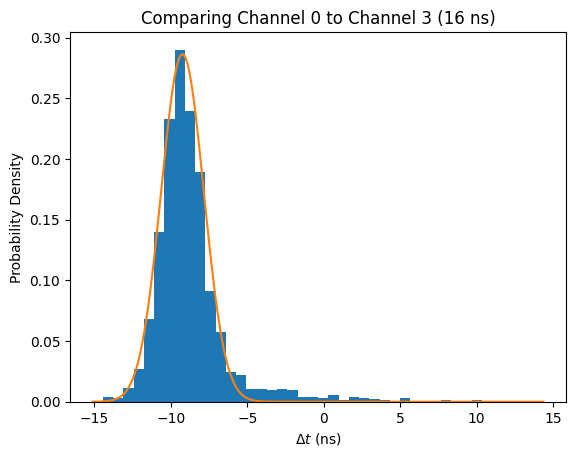

16 - μ: -9.240084 ns, σ: 1.393721 ns


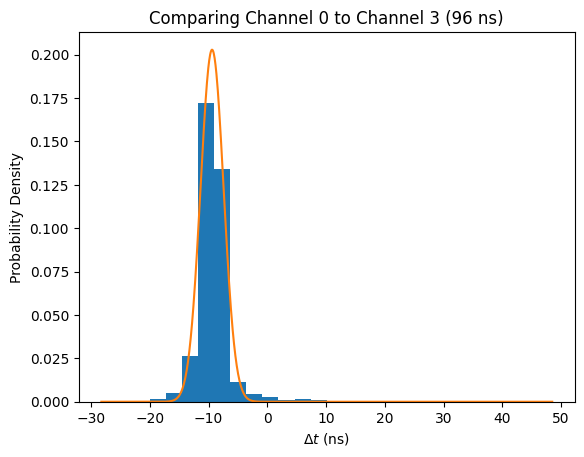

96 - μ: -9.399655 ns, σ: 1.966133 ns


([{16: 0, 96: 0},
  {16: np.float64(7.944644472822425), 96: np.float64(8.069949604885693)},
  {16: np.float64(7.598107510382134), 96: np.float64(7.470075046964796)},
  {16: np.float64(9.240083674901616), 96: np.float64(9.399655226430962)}],
 [{16: 0, 96: 0},
  {16: np.float64(2.195738694157154), 96: np.float64(2.215972392669772)},
  {16: np.float64(1.8781215843258343), 96: np.float64(2.044317338269365)},
  {16: np.float64(1.3937205691971883), 96: np.float64(1.9661330697873727)}])

In [7]:
compare_timing(0,data_dict,display=True)

In [73]:
def timing_info(data, display=True):
   max_diffs, ch1s, ch2s, outers, no_inners,missed_inner = [],[],[],[],[],[]
   t0,t1,t2,t3 = data[0].db['Time']*1e9,data[1].db['Time']*1e9,data[2].db['Time']*1e9,data[3].db['Time']*1e9
   indices = [0,0,0,0]
   if display:
      print(f'       t0       | Time to Other Side |       Ch1      |       Ch2      | Max Difference Between Outer and Inner |')
      print( '----------------+--------------------+----------------+----------------+----------------------------------------+')
   while indices[0]<len(t0):
      i0,i1,i2,i3 = indices
      outer = t3[i3]-t0[i0]
      outers.append(outer)
      ch1 = t1[i1]-t0[i0]
      ch1s.append(ch1)
      ch2 = t2[i2]-t0[i0]
      ch2s.append(ch2)
      ch1_max, ch2_max = max(np.abs(t0[i0]-t1[i1]),np.abs(t3[i3]-t1[i1])), max(np.abs(t0[i0]-t2[i2]),np.abs(t3[i3]-t2[i2]))
      max_diff = max(ch1_max, ch2_max)
      max_diffs.append(max_diff)

      if np.abs(ch1) > 100 and np.abs(ch2) > 100:
         no_inners.append(np.array([i0,i1,i2,i3]))

      if np.abs(ch1) > 100 or np.abs(ch2) > 100:
         missed_inner.append(np.array([i0,i1,i2,i3]))

      indices[0] += 1
      if ch1_max < 100: indices[1] += 1
      if ch2_max < 100: indices[2] += 1
      indices[3] += 1

      if display:
         print(f'{t0[i0]/1e9:>13.0f} s |', end='')
         print(f'{outer:>16.3g} ns |', end='')
         print(f'{ch1:>12.3g} ns |', end='')
         print(f'{ch2:>12.3g} ns |', end='')
         print(f'{max_diff:>36.2f} ns |')
         print( '----------------+--------------------+----------------+----------------+----------------------------------------+')
   return np.array(max_diffs), np.array(ch1s), np.array(ch2s), np.array(outers), np.array(no_inners), np.array(missed_inner)

print('=== 16 ns: ===\n')
max_diff_16, ch1_16, ch2_16, outers_16, no_inners_16, missed_inner_16 = timing_info(data16)

print('\n=== 96 ns: ===\n')
max_diff_96, ch1_96, ch2_96, outers_96, no_inners_96, missed_inner_96 = timing_info(data96)

print('\n=== Test 3: ===\n')
timing_info(data23)

=== 16 ns: ===

       t0       | Time to Other Side |       Ch1      |       Ch2      | Max Difference Between Outer and Inner |
----------------+--------------------+----------------+----------------+----------------------------------------+
           26 s |            8.75 ns |        11.7 ns |        7.75 ns |                               11.75 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
           72 s |            11.5 ns |        17.5 ns |    1.36e+10 ns |                      13595762520.50 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
           86 s |            8.94 ns |        11.1 ns |        7.63 ns |                               11.12 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
           88 s |            11.5 ns |           6 ns |        9.25 ns |

IndexError: index 603 is out of bounds for axis 0 with size 603

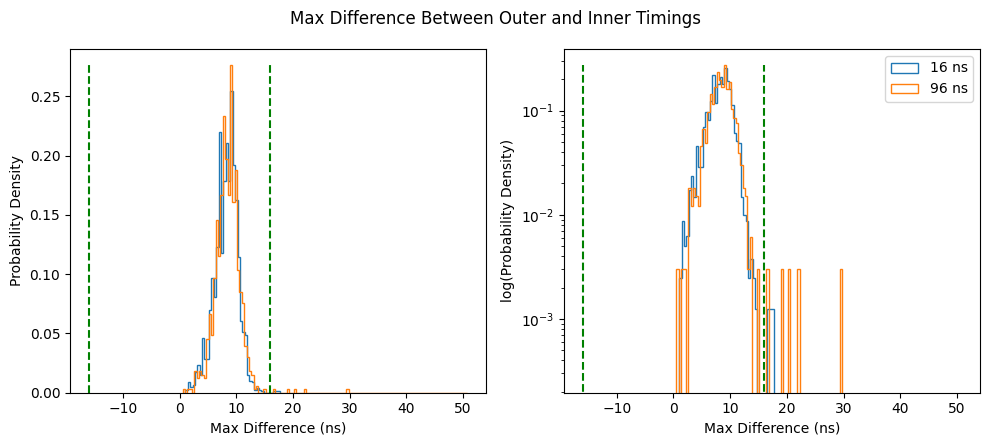

17.75 51.0
1.0078125 0.5009765625


In [19]:
def timing_hist(arr16, arr96, title, xlabel, binning_method='fd'):
   fig, axs = plt.subplots(1,2,figsize=(10,4.5))
   fig.suptitle(title)
   axs[0].set_xlabel(xlabel)
   axs[1].set_xlabel(xlabel)
   axs[0].set_ylabel('Probability Density')
   axs[1].set_ylabel('log(Probability Density)')
   n16,bins16,_ = axs[0].hist(arr16,label='16 ns',histtype='step',bins=binning_method,density=True)
   bins96 = np.arange(np.min(arr96),np.max(arr96),bins16[1]-bins16[0])
   n96,_,_ = axs[0].hist(arr96,label='96 ns',histtype='step',bins=bins96,density=True)
   xs,ys = [np.full(1000,16),np.full(1000,-16)],np.linspace(0,max(np.max(n16),np.max(n96)),1000)
   axs[0].plot(xs[0],ys,linestyle='--',color='green')
   axs[0].plot(xs[1],ys,linestyle='--',color='green')

   n16,bins16,_ = axs[1].hist(arr16,label='16 ns',histtype='step',bins=binning_method,density=True)
   n96,_,_ = axs[1].hist(arr96,label='96 ns',histtype='step',bins=bins96,density=True)
   xs,ys = [np.full(1000,16),np.full(1000,-16)],np.linspace(0,max(np.max(n16),np.max(n96)),1000)
   axs[1].plot(xs[0],ys,linestyle='--',color='green')
   axs[1].plot(xs[1],ys,linestyle='--',color='green')
   axs[1].set_yscale('log')
   plt.legend()
   plt.tight_layout()
   plt.show()

max_diff_16 = max_diff_16[max_diff_16 < 500]
max_diff_96 = max_diff_96[max_diff_96 < 500]
timing_hist(max_diff_16,max_diff_96,"Max Difference Between Outer and Inner Timings","Max Difference (ns)")

print(np.max(max_diff_16),np.max(max_diff_96))
print(np.min(max_diff_16),np.min(max_diff_96))

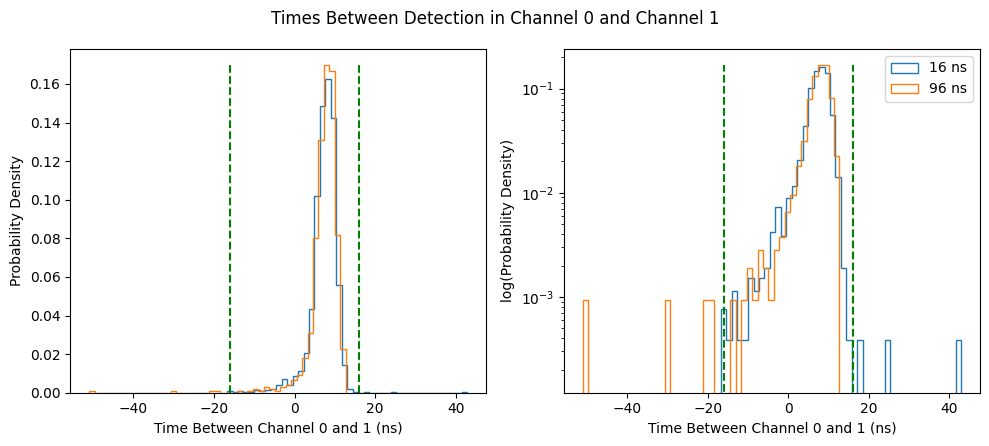

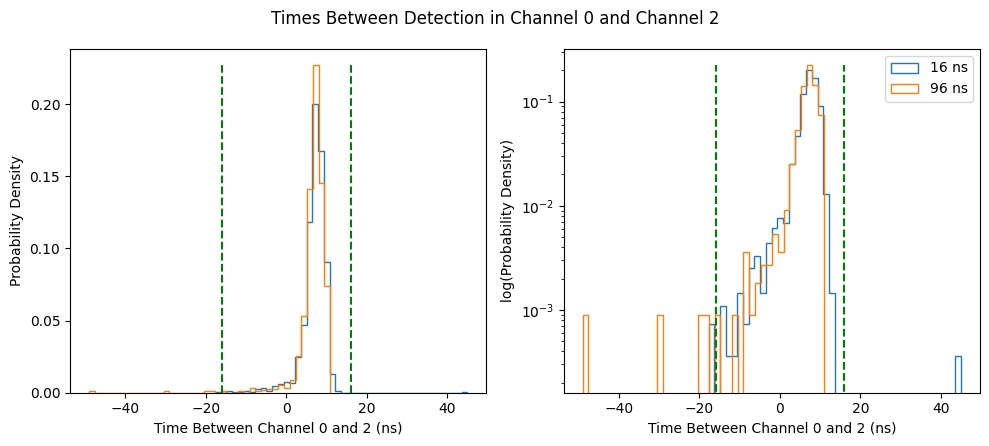

In [21]:
ch1_16 = ch1_16[np.abs(ch1_16) < 500]
ch1_96 = ch1_96[np.abs(ch1_96) < 500]
timing_hist(ch1_16,ch1_96,"Times Between Detection in Channel 0 and Channel 1","Time Between Channel 0 and 1 (ns)",binning_method=round(np.sqrt(len(ch1_16))))

ch2_16 = ch2_16[np.abs(ch2_16) < 500]
ch2_96 = ch2_96[np.abs(ch2_96) < 500]
timing_hist(ch2_16,ch2_96,"Times Between Detection in Channel 0 and Channel 2","Time Between Channel 0 and 2 (ns)",binning_method=round(np.sqrt(len(ch2_16))))

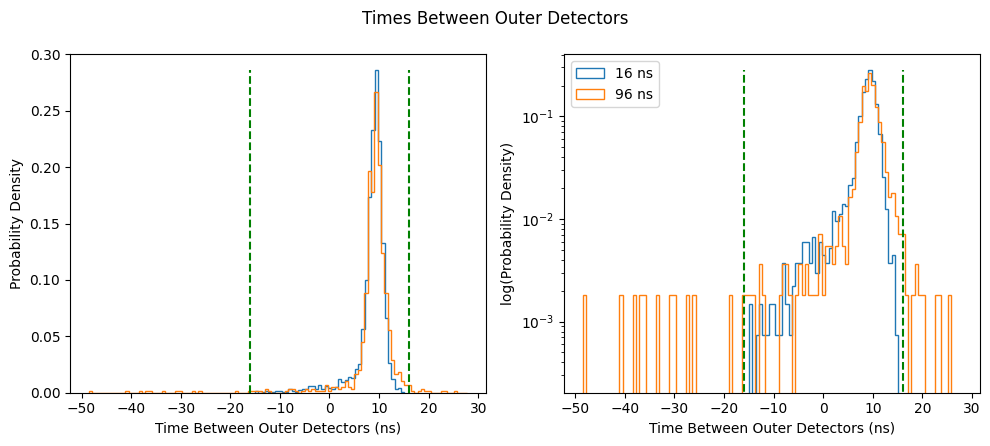

In [26]:
timing_hist(outers_16,outers_96,"Times Between Outer Detectors","Time Between Outer Detectors (ns)",binning_method=round(np.sqrt(len(outers_16))))

In [27]:
print(len(outers_16),len(outers_16[outers_16<0]),len(outers_16[outers_16<0])/len(outers_16))
print(len(outers_96),len(outers_96[outers_96<0]),len(outers_96[outers_96<0])/len(outers_96))
print(f'16 ns: ({np.min(outers_16):.2f}, {np.max(outers_16):.2f})')
print(f'96 ns: ({np.min(outers_96):.2f}, {np.max(outers_96):.2f})')

2017 77 0.03817550818046604
830 37 0.04457831325301205
16 ns: (-14.99, 15.12)
96 ns: (-48.50, 28.25)


In [30]:
print(len(outers_16),len(no_inners_16),len(no_inners_16)/len(outers_16))
print(len(outers_96),len(no_inners_96),len(no_inners_96)/len(outers_96))

2017 83 0.04115022310361924
830 40 0.04819277108433735


In [35]:
print(f'       t0       | Time to Other Side |       Ch1      |       Ch2      | Max Difference Between Outer and Inner |')
print( '================+====================+================+================+========================================+')
for indices in no_inners_96:

   i0,i1,i2,i3 = indices
   t0 = data96[0].db['Time']*1e9
   outer,ch1,ch2,max_diff = outers_96[i0],ch1_96[i0],ch2_96[i0],max_diff_96[i0]

   print(f'{t0[i0]/1e9:>13.0f} s |', end='')
   print(f'{outer:>16.3g} ns |', end='')
   print(f'{ch1:>12.3g} ns |', end='')
   print(f'{ch2:>12.3g} ns |', end='')
   print(f'{max_diff:>36.2f} ns |')
   print( '----------------+--------------------+----------------+----------------+----------------------------------------+')

       t0       | Time to Other Side |       Ch1      |       Ch2      | Max Difference Between Outer and Inner |
================+====================+================+================+========================================+
          141 s |            12.3 ns |    9.44e+09 ns |    9.44e+09 ns |                       9443667573.50 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
         1531 s |           -12.4 ns |    5.14e+09 ns |    5.14e+09 ns |                       5138330702.44 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
         1614 s |            14.5 ns |    2.43e+10 ns |    2.43e+10 ns |                      24300006539.00 ns |
----------------+--------------------+----------------+----------------+----------------------------------------+
         2391 s |               3 ns |    1.68e+10 ns |    1.68e+10 ns |                

In [42]:
# for indices in no_inners_96:
#    t0 = data96[0].db['Time'][indices[0]]
#    ttos = outers_96[indices[0]]
#    signal0,signal3 = data96[0].db['Signal'][indices[0]],data96[3].db['Signal'][indices[3]]
#    ts = np.arange(0,996)

#    fig, axs = plt.subplots(1,2,figsize=(10,4.5))
#    fig.suptitle(f'$t_0={t0:.2f}$ s, TTOS: {ttos:.2f} ns')

#    axs[0].set_title('Channel 0')
#    axs[1].set_title('Channel 3')
#    axs[0].set_xlabel('Time (ns)')
#    axs[1].set_xlabel('Time (ns)')
#    axs[0].set_ylabel('Signal (mV)')

#    print(ts.shape,signal0.shape)
#    axs[0].plot(ts,signal0)
#    axs[1].plot(ts,signal3)
#    plt.tight_layout()
#    plt.show()

4.610808130887457 4.1150223103619235
5.0602409638554215 4.819277108433735
[np.float64(21.526555881394604), np.float64(38.08895405669601), np.float64(54.65135223199741), np.float64(71.2137504072988), np.float64(87.77614858260021), np.float64(104.33854675790163), np.float64(120.90094493320301), np.float64(137.46334310850443), np.float64(154.02574128380584), np.float64(170.58813945910725), np.float64(187.15053763440864), np.float64(203.71293580971005), np.float64(220.27533398501146), np.float64(236.83773216031284), np.float64(253.40013033561428), np.float64(269.96252851091566), np.float64(286.52492668621704), np.float64(303.0873248615185), np.float64(319.64972303681986), np.float64(336.2121212121213), np.float64(352.7745193874227), np.float64(369.33691756272407), np.float64(385.8993157380255), np.float64(402.4617139133269), np.float64(419.02411208862827), np.float64(435.5865102639297), np.float64(452.1489084392311), np.float64(468.7113066145325), np.float64(485.2737047898339), np.float64(

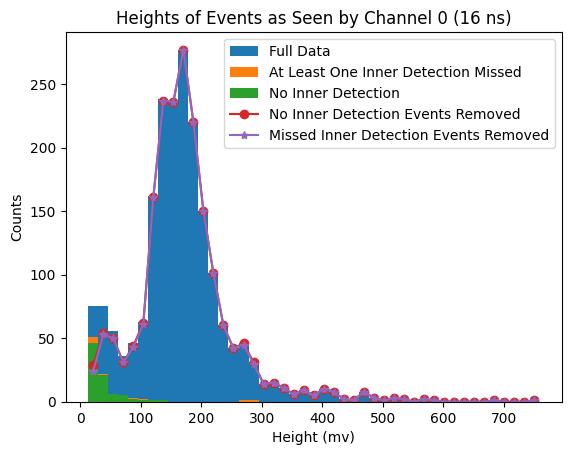

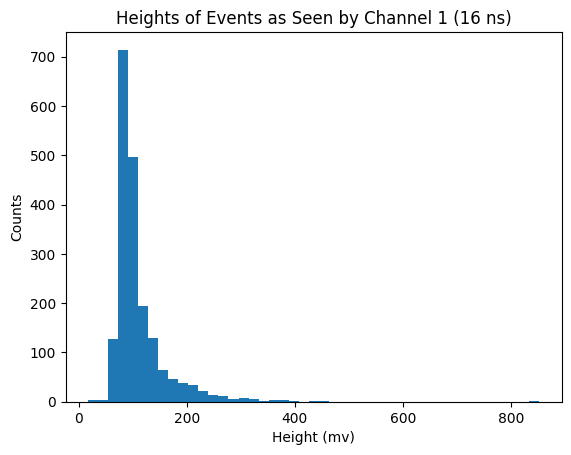

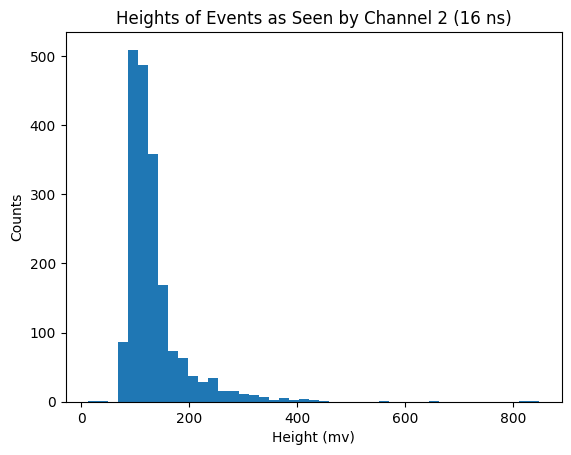

[np.float64(23.739002932551312), np.float64(42.18475073313782), np.float64(60.630498533724335), np.float64(79.07624633431085), np.float64(97.52199413489735), np.float64(115.96774193548387), np.float64(134.41348973607037), np.float64(152.85923753665688), np.float64(171.30498533724338), np.float64(189.75073313782988), np.float64(208.1964809384164), np.float64(226.64222873900292), np.float64(245.08797653958942), np.float64(263.5337243401759), np.float64(281.9794721407624), np.float64(300.4252199413489), np.float64(318.87096774193543), np.float64(337.31671554252193), np.float64(355.76246334310844), np.float64(374.20821114369494), np.float64(392.6539589442815), np.float64(411.099706744868), np.float64(429.5454545454545), np.float64(447.991202346041), np.float64(466.4369501466275), np.float64(484.882697947214), np.float64(503.3284457478005), np.float64(521.7741935483871), np.float64(540.2199413489735), np.float64(558.6656891495601), np.float64(577.1114369501465), np.float64(595.5571847507331

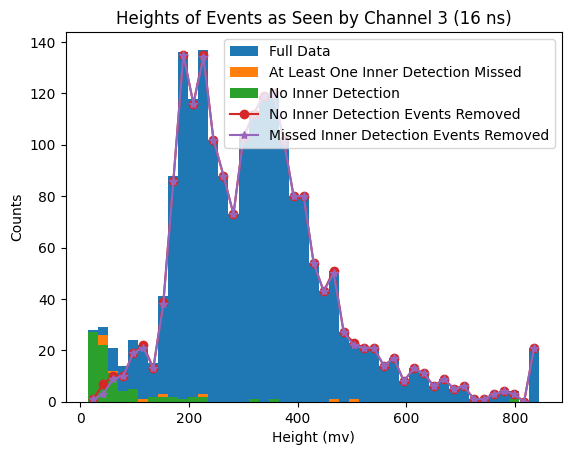

[np.float64(25.4533656925203), np.float64(54.46371389085515), np.float64(83.47406208919), np.float64(112.48441028752487), np.float64(141.4947584858597), np.float64(170.50510668419457), np.float64(199.51545488252944), np.float64(228.52580308086428), np.float64(257.5361512791991), np.float64(286.5464994775339), np.float64(315.5568476758688), np.float64(344.56719587420366), np.float64(373.5775440725385), np.float64(402.5878922708734), np.float64(431.59824046920824), np.float64(460.6085886675431), np.float64(489.6189368658779), np.float64(518.6292850642127), np.float64(547.6396332625476), np.float64(576.6499814608824), np.float64(605.6603296592173), np.float64(634.6706778575522), np.float64(663.681026055887), np.float64(692.6913742542218), np.float64(721.7017224525567), np.float64(750.7120706508915), np.float64(779.7224188492264), np.float64(808.7327670475613), np.float64(837.7431152458961)]


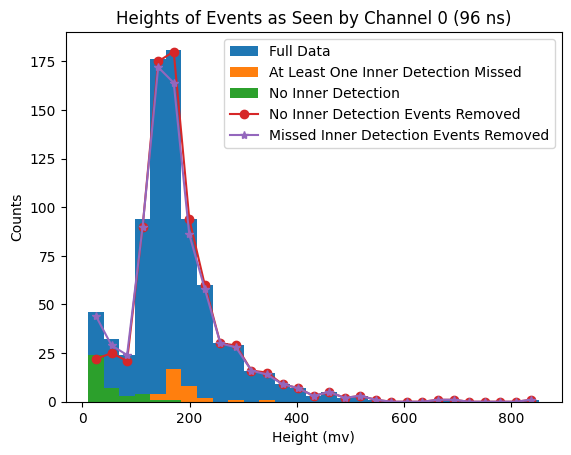

[np.float64(26.933967034078275), np.float64(52.160649880338426), np.float64(77.38733272659857), np.float64(102.61401557285873), np.float64(127.84069841911888), np.float64(153.06738126537903), np.float64(178.2940641116392), np.float64(203.52074695789935), np.float64(228.7474298041595), np.float64(253.97411265041967), np.float64(279.2007954966798), np.float64(304.42747834293993), np.float64(329.6541611892001), np.float64(354.88084403546026), np.float64(380.10752688172045), np.float64(405.3342097279806), np.float64(430.5608925742407), np.float64(455.7875754205009), np.float64(481.01425826676103), np.float64(506.2409411130213), np.float64(531.4676239592814), np.float64(556.6943068055415), np.float64(581.9209896518016), np.float64(607.1476724980618), np.float64(632.374355344322), np.float64(657.6010381905821), np.float64(682.8277210368423), np.float64(708.0544038831024), np.float64(733.2810867293625)]


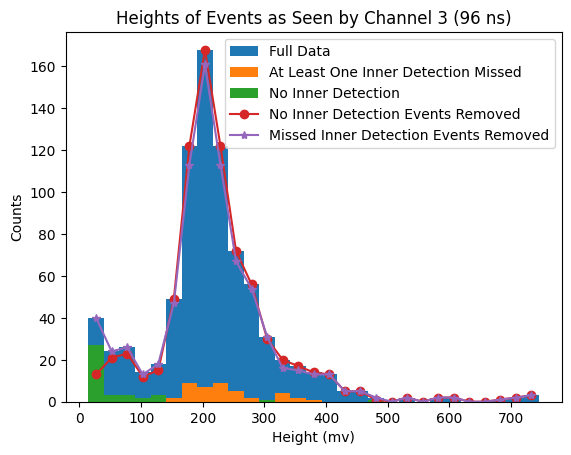

In [ ]:
heights016 = data16[0].db['Height']
heights096 = data96[0].db['Height']
heights016_no_inners = heights016[np.transpose(no_inners_16)[0]]
heights016_missed_inner = heights016[np.transpose(missed_inner_16)[0]]
heights096_no_inners = heights096[np.transpose(no_inners_96)[0]]
heights096_missed_inner = heights016[np.transpose(missed_inner_96)[0]]
print(len(heights016_missed_inner)/len(heights016)*100,len(heights016_no_inners)/len(heights016)*100)
print(len(heights096_missed_inner)/len(heights096)*100,len(heights096_no_inners)/len(heights096)*100)
print(len(heights016)-len(heights016_no_inners))

heights316 = data16[3].db['Height']
heights396 = data96[3].db['Height']
heights316_no_inners = heights316[np.transpose(no_inners_16)[3]]
heights316_missed_inner = heights316[np.transpose(missed_inner_16)[3]]
heights396_no_inners = heights396[np.transpose(no_inners_96)[3]]
heights396_missed_inner = heights316[np.transpose(missed_inner_96)[3]]

plt.title("Heights of Events as Seen by Channel 0 (16 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(heights016,bins=round(np.sqrt(len(heights016))), label='Full Data')
n_missed,_,_ = plt.hist(heights016_missed_inner,bins=bins, label='At Least One Inner Detection Missed')
n_no,_,_ = plt.hist(heights016_no_inners,bins=bins, label='No Inner Detection')
bin_width = bins[1]-bins[0]
print([bins[i+1]-bin_width/2 for i in range(len(bins)-1)])
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_no,marker='o',label='No Inner Detection Events Removed')
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_missed,marker='*',label='Missed Inner Detection Events Removed')
plt.legend()
plt.show()

plt.title("Heights of Events as Seen by Channel 1 (16 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(data16[1].db['Height'],bins=round(np.sqrt(len(heights016))), label='Full Data')
plt.show()

plt.title("Heights of Events as Seen by Channel 2 (16 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(data16[2].db['Height'],bins=round(np.sqrt(len(heights016))), label='Full Data')
plt.show()

plt.title("Heights of Events as Seen by Channel 3 (16 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(heights316,bins=round(np.sqrt(len(heights316))), label='Full Data')
n_missed,_,_ = plt.hist(heights316_missed_inner,bins=bins, label='At Least One Inner Detection Missed')
n_no,_,_ = plt.hist(heights316_no_inners,bins=bins, label='No Inner Detection')
bin_width = bins[1]-bins[0]
print([bins[i+1]-bin_width/2 for i in range(len(bins)-1)])
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_no,marker='o',label='No Inner Detection Events Removed')
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_missed,marker='*',label='Missed Inner Detection Events Removed')
plt.legend()
plt.show()

plt.title("Heights of Events as Seen by Channel 0 (96 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(heights096,bins=round(np.sqrt(len(heights096))), label='Full Data')
n_missed,_,_ = plt.hist(heights096_missed_inner,bins=bins, label='At Least One Inner Detection Missed')
n_no,_,_ = plt.hist(heights096_no_inners,bins=bins, label='No Inner Detection')
bin_width = bins[1]-bins[0]
print([bins[i+1]-bin_width/2 for i in range(len(bins)-1)])
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_no,marker='o',label='No Inner Detection Events Removed')
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_missed,marker='*',label='Missed Inner Detection Events Removed')
plt.legend()
plt.show()

plt.title("Heights of Events as Seen by Channel 3 (96 ns)")
plt.xlabel('Height (mv)')
plt.ylabel('Counts')
n_full,bins,_ = plt.hist(heights396,bins=round(np.sqrt(len(heights396))), label='Full Data')
n_missed,_,_ = plt.hist(heights396_missed_inner,bins=bins, label='At Least One Inner Detection Missed')
n_no,_,_ = plt.hist(heights396_no_inners,bins=bins, label='No Inner Detection')
bin_width = bins[1]-bins[0]
print([bins[i+1]-bin_width/2 for i in range(len(bins)-1)])
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_no,marker='o',label='No Inner Detection Events Removed')
plt.plot([bins[i+1]-bin_width/2 for i in range(len(bins)-1)],n_full-n_missed,marker='*',label='Missed Inner Detection Events Removed')
plt.legend()
plt.show()
